In [5973]:
!pip3 install opencv-python
!pip3 install seaborn
!pip3 install tensorflow 

In [5974]:

import tensorflow as tf
import cv2
import numpy as np
import math
from matplotlib import pyplot as plt
import seaborn as sns
import time
import os

In [5975]:
import homography_utility as h

In [5976]:
patch_size = h.patch_size
kernel_size = h.patch_size
image_size = h.image_size
descriptor_dimension = h.descriptor_dimension

max_rotation = h.max_rotation
rotation_multiple = h.rotation_multiple
max_skew = h.max_skew

margin = h.margin
threshold = h.threshold
learning_rate = h.learning_rate
optimizer = h.optimizer
cos_sim = h.cos_sim
batch_size = h.batch_size
epochs = h.epochs
num_filters = h.num_filters
model_path = h.backup_model_path
backup_model_path = h.backup_model_path

In [5977]:
#get a random image and get all keypoint and get 32 X 32 pixels around it
dir ='real_images'
list_of_images = os.listdir(dir)
image_name=".DS_Store"
while(image_name == ".DS_Store"):
    image_name = np.random.choice(list_of_images)

print('chosen image is' , image_name)
image_path  = os.path.join(dir,image_name)
print('chosen image path is' , image_path)



chosen image is 80px-Cathedrale-de-Strasbourg-IMG_1361.jpg
chosen image path is real_images/80px-Cathedrale-de-Strasbourg-IMG_1361.jpg


In [5978]:
#load the image and get all keypoints
image  = cv2.imread(image_path)
image = cv2.resize(image, (image_size, image_size))
orb= cv2.ORB_create(100)
kp = orb.detect(image)


In [5979]:
#select a keypoint that has atleast patch_size/2 pixels around it
got = False
x=0
y=0
k=0
while(not got):
    k=np.random.choice(kp)
    if(k.pt[0] >patch_size/2 and k.pt[1] >patch_size/2 and k.pt[1]<image_size-(patch_size/2 )and k.pt[0]<image_size-(patch_size/2)):
        got=True

print(k.pt)

(216.0, 167.0)


In [5980]:
#draw the point on image and get rotated images
transformed_image = cv2.warpPerspective(image, h.get_random_homography_matrix(True), (image_size, image_size))
cv2.circle(image,(int(k.pt[0]),int(k.pt[1])),3,(255,0,0))



array([[[185, 193, 153],
        [191, 199, 159],
        [204, 212, 172],
        ...,
        [228, 220, 180],
        [231, 223, 183],
        [232, 224, 184]],

       [[186, 194, 154],
        [191, 199, 160],
        [202, 210, 171],
        ...,
        [229, 221, 181],
        [232, 224, 184],
        [233, 225, 185]],

       [[187, 195, 157],
        [190, 198, 161],
        [198, 206, 169],
        ...,
        [231, 223, 183],
        [233, 225, 185],
        [234, 226, 186]],

       ...,

       [[  6,   7,  21],
        [  8,   9,  23],
        [ 12,  13,  27],
        ...,
        [ 83,  81,  93],
        [ 88,  86,  98],
        [ 90,  88, 100]],

       [[ 14,  15,  29],
        [ 13,  14,  28],
        [ 13,  14,  28],
        ...,
        [ 81,  79,  91],
        [ 84,  82,  94],
        [ 85,  83,  95]],

       [[ 18,  19,  33],
        [ 16,  17,  31],
        [ 13,  14,  28],
        ...,
        [ 80,  78,  90],
        [ 82,  80,  92],
        [ 83,  81,  93]]

In [5981]:
#get all keypoints in random rotation 
kp_random  = orb.detect(transformed_image)


In [5982]:
img =image
img_t=transformed_image

image = cv2.cvtColor(image,cv2.COLOR_RGB2GRAY)
transformed_image = cv2.cvtColor(transformed_image,cv2.COLOR_RGB2GRAY)

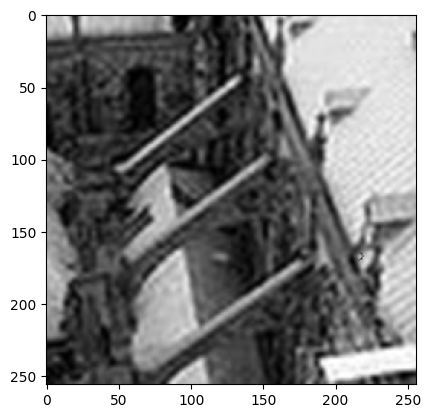

In [5983]:
#convert ll to greyscale

plt.imshow(image,cmap='gray')

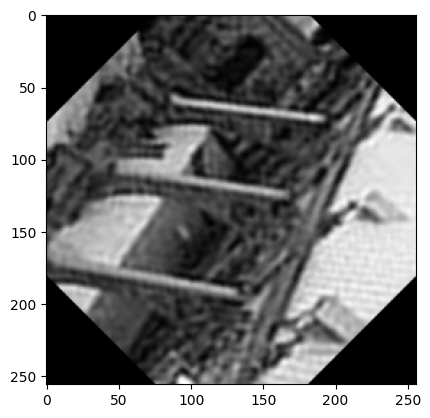

In [5984]:
plt.imshow(transformed_image,cmap='gray')

In [5985]:
#create a function that will describe a patch around a keypoint 
filters = np.load('learned_filters/learned_filters_chnnel_8.npy')
print('filters are ',filters.shape)
def describe_patch(image, kp):
    patch = tf.convert_to_tensor(image[int(kp.pt[1]-patch_size/2):int(kp.pt[1]+patch_size/2), int(kp.pt[0]-patch_size/2):int(kp.pt[0]+patch_size/2)],dtype=tf.double)
    activated_filer = tf.keras.activations.tanh(tf.convert_to_tensor(filters))
    # print('activated_filer is ',activated_filer.shape)
    patch = tf.repeat(tf.expand_dims(patch,-1),num_filters,-1)
    # print('patch_size',patch.shape)
    operated_patch = tf.multiply(activated_filer,patch)
    final_vector = tf.reduce_mean(operated_patch,[0,1])
    # print('final vector is',final_vector.shape)
    return  final_vector

filters are  (32, 32, 8)


In [5986]:
desc_original_kp = describe_patch(image,k)
print(desc_original_kp)

tf.Tensor(
[ 1.17338833  0.02335644 -1.27191866 -1.67666408  1.91012618 -0.35838031
  1.5877298   0.91146656], shape=(8,), dtype=float64)


In [5987]:
#describe every kp in transformed image and print the best match 
max_pt =kp_random[0]
max_similarity = -cos_sim(desc_original_kp,describe_patch(transformed_image,max_pt))
second_max_similarity =max_similarity

for t_kp in kp_random:
    desc_t_kp = describe_patch(transformed_image,t_kp)
    similarity = -cos_sim(desc_original_kp,desc_t_kp)
    if(similarity > max_similarity):
        second_max_similarity = max_similarity
        max_similarity = similarity
        max_pt = t_kp
   

In [5988]:
img=cv2.circle(img,(int(k.pt[0]),int(k.pt[1])),6,(255,0,0),-1)
img_t=cv2.circle(img_t,(int(max_pt.pt[0]),int(max_pt.pt[1])),6,(255,0,0),-1)
print('done')


done


0.9241482 0.6050024 0.6546595


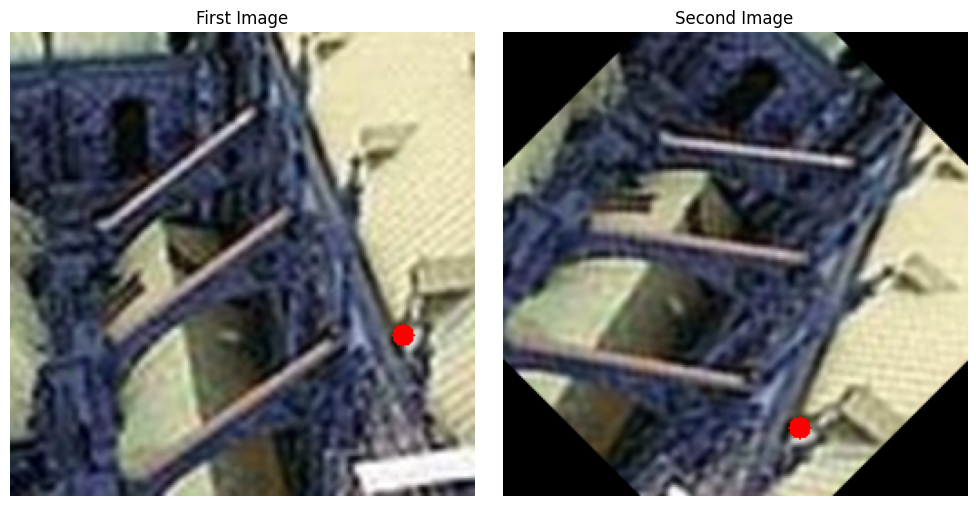

In [5989]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img)
axes[0].set_title('First Image')
axes[0].axis('off')

# Plot the second image
axes[1].imshow(img_t)
axes[1].set_title('Second Image')
axes[1].axis('off')
print(max_similarity.numpy(),second_max_similarity.numpy() , (second_max_similarity/max_similarity).numpy())

# Display the plot
plt.tight_layout()
plt.show()